# Retail Customer Segmentation Analysis

This project analyzes an online retail dataset to understand customer purchasing behavior.  
Using RFM (Recency, Frequency, Monetary) analysis, customers are segmented into different behavioral groups such as Champions, Loyal Customers, Potential Customers, and Lost Customers.

The goal of this analysis is to help businesses understand customer value and design targeted marketing strategies.

# Business Objective

The objective of this project is to analyze customer purchasing behavior using transactional retail data.

By applying RFM (Recency, Frequency, Monetary) analysis, customers are segmented into different behavioral groups based on how recently they purchased, how often they purchase, and how much they spend.

This segmentation helps identify high-value customers, detect inactive customers, and understand purchasing patterns. These insights can support businesses in designing targeted marketing strategies, improving customer retention, and maximizing revenue.

# Data Understanding

The dataset used in this project contains transactional data from an online retail store.

Each row represents a product purchased in a transaction and includes details such as:

- Invoice number
- Product code and description
- Quantity purchased
- Invoice date
- Product price
- Customer ID
- Country of the customer

This information allows us to analyze customer purchasing behavior and perform RFM (Recency, Frequency, Monetary) analysis.

### Load Dataset

In [1]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Dataset Overview

### Dataset Size

In [2]:
df.shape

(525461, 8)

### Column Names

In [3]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

### Missing Values

In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

### Observations

The dataset contains missing values mainly in the **Customer ID** and **Description** columns.

Since customer segmentation requires identifying unique customers, rows with missing **Customer ID** will be removed during the data cleaning stage.

### Detect Cancelled Orders

In this dataset, cancelled transactions can be identified because their invoice numbers start with the letter **"C"**.

These records represent product returns or cancelled purchases and should be examined before performing further analysis.

In [5]:
df[df['Invoice'].astype(str).str.startswith('C')].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


## Cancellled Orders Count

In [6]:
df['Invoice'].astype(str).str.startswith('C').sum()

np.int64(10206)

### Detect Product Returns (Negative Quantity)

In this dataset, returned products are represented by **negative quantity values**.  
These records indicate that a product was returned by the customer after purchase.

Before performing further analysis, we identify these transactions so that we can decide whether to remove them or handle them appropriately during the data cleaning stage.

In [7]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [8]:
(df['Quantity']<0).sum()

np.int64(12326)

### Data Cleaning

After identifying cancelled orders and product returns, we clean the dataset by removing transactions with negative quantities.

Negative quantities represent returned items or cancelled purchases.  
For customer behavior analysis, we keep only **valid purchase transactions** where the quantity is greater than zero.

In [9]:
df_clean = df[df['Quantity'] > 0].copy()

In [10]:
df_clean.shape

(513135, 8)

In [11]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Create Revenue Column

In [12]:
df_clean.loc[:, 'Revenue'] = df_clean['Quantity'] * df_clean['Price']

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Calculate Business KPIs

After cleaning the dataset and creating the Revenue column, we calculate some key business metrics (KPIs).

These metrics provide a high-level overview of the business performance and customer activity in the dataset.

The main KPIs we calculate are:

- Total Revenue generated
- Total number of unique orders
- Total number of unique customers

1. Total Revenue

In [13]:
round(df_clean['Revenue'].sum(),2)

np.float64(10169713.57)

2. Total Orders

In [14]:
df_clean['Invoice'].nunique()

22104

3. Total Customers

In [15]:
df_clean['Customer ID'].nunique()

4314

## Top 10 Best Selling Products

In [16]:
top_products = (
    df_clean
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    58793
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55202
BROCADE RING PURSE                    48384
PACK OF 72 RETRO SPOT CAKE CASES      46755
ASSORTED COLOUR BIRD ORNAMENT         45356
60 TEATIME FAIRY CAKE CASES           36502
PACK OF 60 PINK PAISLEY CAKE CASES    31940
JUMBO BAG RED RETROSPOT               30807
SMALL POPCORN HOLDER                  29824
STRAWBERRY CERAMIC TRINKET BOX        27128
Name: Quantity, dtype: int64

## Revenue by Country

In [17]:
revenue_country=df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
revenue_country

Country
United Kingdom    8709577.243
EIRE               380977.820
Netherlands        268786.000
Germany            202395.321
France             147211.490
Sweden              53525.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

### Sales Trends Over Time

To understand how business performance changes over time, we analyze monthly revenue trends.

By grouping transactions by month and summing the revenue, we can observe how sales increase or decrease across different months.

In [18]:
df_clean.loc[:, 'InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean.loc[:, 'Month'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('Month')['Revenue'].sum()
monthly_revenue.head()

Month
2009-12    825685.760
2010-01    652708.502
2010-02    553713.306
2010-03    833570.131
2010-04    627934.632
Freq: M, Name: Revenue, dtype: float64

### Trend Visualization

To better understand the sales trend over time, we visualize the monthly revenue using a line chart.

This visualization helps identify patterns such as growth periods, seasonal fluctuations, and potential declines in sales. Observing these trends can help businesses make data-driven decisions regarding marketing strategies, inventory planning, and future sales forecasting.

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

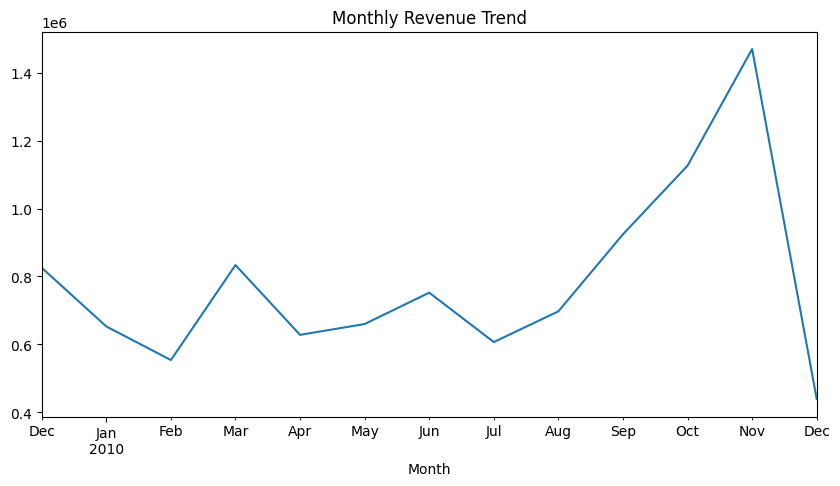

In [19]:
monthly_revenue.plot(figsize=(10,5), title="Monthly Revenue Trend")

### RFM Customer Segmentation

To better understand customer purchasing behavior, we apply **RFM analysis**.

RFM stands for:

- **Recency (R):** How recently a customer made a purchase
- **Frequency (F):** How often a customer makes purchases
- **Monetary (M):** How much money a customer spends

By calculating these three metrics for each customer, we can segment customers based on their purchasing behavior and identify valuable customer groups.

In [20]:
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate':'max',
    'Invoice':'nunique',
    'Revenue':'sum'
})
rfm.columns=['LastPurchaseDate','Frequency','Monetary']
rfm.head()

,LastPurchaseDate,Frequency,Monetary
Customer ID,,,
12346.0,2010-06-28 13:53:00,11,372.86
12347.0,2010-12-07 14:57:00,2,1323.32
12348.0,2010-09-27 14:59:00,1,222.16
12349.0,2010-10-28 08:23:00,3,2671.14
12351.0,2010-11-29 15:23:00,1,300.93


### Calculate Recency

Recency measures how recently a customer made their last purchase.

To calculate recency, we first determine the **most recent transaction date in the dataset**.  
Then we calculate the number of days between that date and each customer's last purchase.

Customers with lower recency values have purchased more recently and are considered more engaged.

In [21]:
import datetime as dt
current_date=df_clean['InvoiceDate'].max()
rfm['Recency']=(current_date-rfm['LastPurchaseDate']).dt.days
rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency
Customer ID,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164
12347.0,2010-12-07 14:57:00,2,1323.32,2
12348.0,2010-09-27 14:59:00,1,222.16,73
12349.0,2010-10-28 08:23:00,3,2671.14,42
12351.0,2010-11-29 15:23:00,1,300.93,10


### Assign RFM Scores

To categorize customers based on their RFM values, we convert the Recency, Frequency, and Monetary metrics into scores ranging from **1 to 5**.

This is done using **quantile-based binning**, where customers are divided into five groups based on their relative position in the dataset.

- **Recency Score (R):** Lower recency (recent purchases) receives a higher score.
- **Frequency Score (F):** Customers who purchase more frequently receive higher scores.
- **Monetary Score (M):** Customers who spend more money receive higher scores.

These scores help standardize customer behavior for segmentation analysis.

In [22]:
rfm['R_score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])

rfm['F_score']=pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score']=pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score
Customer ID,,,,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164,2,5,2
12347.0,2010-12-07 14:57:00,2,1323.32,2,5,2,4
12348.0,2010-09-27 14:59:00,1,222.16,73,2,1,1
12349.0,2010-10-28 08:23:00,3,2671.14,42,3,3,5
12351.0,2010-11-29 15:23:00,1,300.93,10,5,1,2


### Combine RFM Scores

After calculating the individual R, F, and M scores, we combine them into a single **RFM score**.

This combined score represents the overall value of each customer based on their purchasing behavior.

In [23]:
rfm['RFM_Score']=(
    rfm['R_score'].astype(str)+
    rfm['F_score'].astype(str)+
    rfm['M_score'].astype(str)
)
rfm.head()


,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164,2,5,2,252
12347.0,2010-12-07 14:57:00,2,1323.32,2,5,2,4,524
12348.0,2010-09-27 14:59:00,1,222.16,73,2,1,1,211
12349.0,2010-10-28 08:23:00,3,2671.14,42,3,3,5,335
12351.0,2010-11-29 15:23:00,1,300.93,10,5,1,2,512


### Customer Segmentation

Using the RFM scores, customers are grouped into different segments based on their purchasing behavior.

These segments help businesses identify valuable customers, loyal customers, and customers who may need re-engagement.

In [24]:
def segment_customer(row):
    
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    
    elif row['R_score'] >= 4:
        return 'Recent Customers'
    
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost Customers'
    
    else:
        return 'Potential Customers'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164,2,5,2,252,Loyal Customers
12347.0,2010-12-07 14:57:00,2,1323.32,2,5,2,4,524,Recent Customers
12348.0,2010-09-27 14:59:00,1,222.16,73,2,1,1,211,Lost Customers
12349.0,2010-10-28 08:23:00,3,2671.14,42,3,3,5,335,Potential Customers
12351.0,2010-11-29 15:23:00,1,300.93,10,5,1,2,512,Recent Customers


# Create Customer Segments Using RFM Scores

After calculating the RFM scores, customers are segmented into different groups based on their purchasing behavior.

The segmentation is based on Recency and Frequency scores:

Champions – Customers who purchased recently and buy frequently.
Loyal Customers – Customers who purchase frequently but may not have purchased recently.
Recent Customers – Customers who purchased recently but do not buy frequently yet.
Potential Customers – Customers with moderate engagement.
Lost Customers – Customers who have not purchased recently and buy rarely.

This segmentation helps businesses identify valuable customers and design targeted marketing strategies.

### Analyze Customer Segment Distribution

In [25]:
rfm['Segment'].value_counts()

Segment
Champions              1105
Lost Customers         1017
Potential Customers     917
Recent Customers        654
Loyal Customers         621
Name: count, dtype: int64

### Revenue Contribution by Customer Segment

In [26]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Champions              5854836.488
Loyal Customers        1458127.742
Potential Customers     680597.850
Recent Customers        428403.690
Lost Customers          410037.504
Name: Monetary, dtype: float64

### Average Customer Value by Segment

In [27]:
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

Segment
Champions              5298.494559
Loyal Customers        2348.031791
Potential Customers     742.200491
Recent Customers        655.051514
Lost Customers          403.183386
Name: Monetary, dtype: float64

## Key Business Insights

Based on the RFM segmentation analysis, several important insights emerge:

• **Champions** generate the highest total revenue and have the highest average spending. These customers are the most valuable and should be retained with loyalty programs and exclusive offers.

• **Loyal Customers** also contribute significant revenue. Businesses should focus on maintaining engagement with personalized promotions.

• **Potential Customers** represent a growth opportunity. Targeted marketing campaigns can help convert them into loyal customers.

• **Recent Customers** have purchased recently but not frequently yet. Encouraging repeat purchases through follow-up offers may increase their lifetime value.

• **Lost Customers** have low recency and frequency. Re-engagement campaigns or special discounts may help recover some of these customers.

## Conclusion

This project analyzed customer purchasing behavior using RFM (Recency, Frequency, Monetary) analysis on an online retail dataset.

Key steps included:

• Data cleaning and preparation  
• Revenue calculation and KPI analysis  
• Sales trend analysis  
• Customer segmentation using RFM scoring  
• Segment-wise revenue and customer value analysis  

The results show that a relatively small group of high-value customers (Champions and Loyal Customers) contributes a significant portion of total revenue.

These insights can help businesses design targeted marketing strategies, improve customer retention, and maximize overall revenue.

### Customer Segment Distribution

To understand how customers are distributed across different RFM segments, we visualize the number of customers in each segment.

This helps identify which customer groups are most common in the dataset and provides an overview of customer engagement levels.

Segments such as **Champions** and **Loyal Customers** represent highly engaged customers, while **Lost Customers** indicate customers who may require re-engagement strategies.

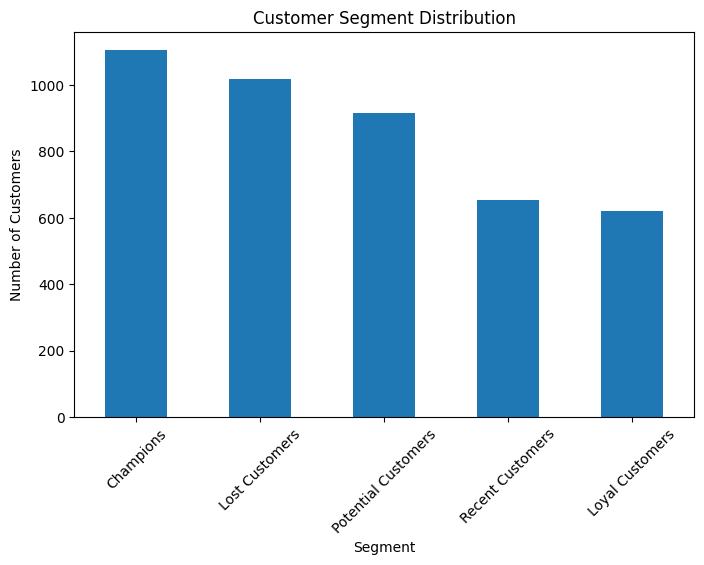

In [28]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(8,5))

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

### Revenue Contribution by Customer Segment

To better understand which customer groups drive the majority of revenue, we visualize the total revenue generated by each RFM segment.

This helps identify the most valuable customer groups and highlights where businesses should focus retention and engagement strategies.

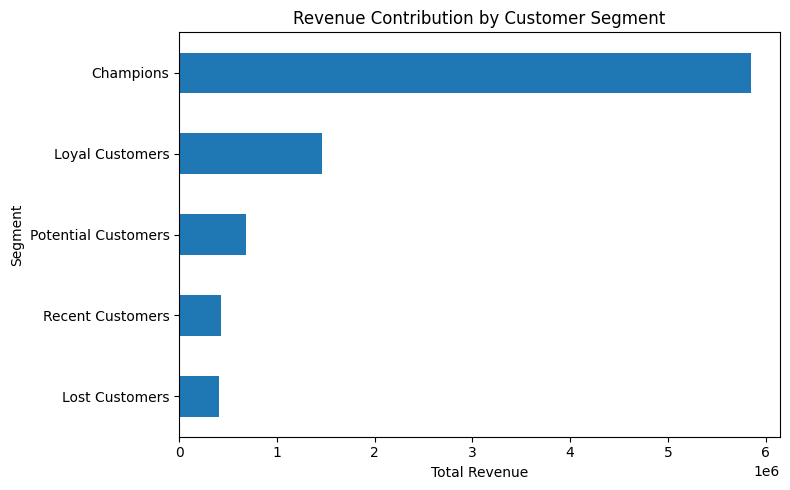

In [29]:
rfm.groupby('Segment')['Monetary'].sum().sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

In [30]:
df_clean.to_csv("retail_clean.csv", index=False)

In [31]:
df_clean.to_csv("retail_powerbi_data.csv", index=False)